In [1]:
import os
from os import PathLike
from pathlib import Path
from functools import partial
%config InlineBackend.figure_formats = ['svg']
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.axes import Axes
from matplotlib.collections import PathCollection
from scipy.stats import gaussian_kde
from typing import Union
import math

import numpy as np
import pandas as pd
plt.style.use('tableau-colorblind10')

def weighted_violinplot(
    dataset: pd.DataFrame,
    value: str,  # name of variable to plot
    *,
    group_by: str | None = None,  # name of variable to group by
    weight: str | None = None,  # name of variable indicating weights
    size: str | None = None,  # name of variable scaling the point sizes
    colour: str | None = None,  # name of variable to colour the points by
    ax: Axes | None = None,
    violin_kwargs: dict | None = None,
    scatter_kwargs: dict | None = None,
) -> tuple[Axes, dict, list[PathCollection] | PathCollection]:
    if scatter_kwargs is None:
        scatter_kwargs = {}
    if violin_kwargs is None:
        violin_kwargs = {}
    vpstats = []
    dataset = dataset.copy()
    if group_by is None:
        dataset["group_by"] = np.ones(dataset.shape[0])
        group_by = "group_by"
    if weight is None:
        dataset["weight"] = np.ones(dataset.shape[0])
        weight = "weight"
    groups = dataset[group_by].unique()
    for group in groups:
        data = dataset.loc[dataset[group_by] == group]
        kde = gaussian_kde(data[value], weights=data[weight])
        coords = np.linspace(data[value].min(), data[value].max(), 1000)
        vals = kde.evaluate(coords)
        mean = data[value].mean()
        median = data[value].median()
        min_ = data[value].min()
        max_ = data[value].max()
        vpstats.append(
            {
                "coords": coords,
                "vals": vals,
                "mean": mean,
                "median": median,
                "min": min_,
                "max": max_,
            },
        )
    ax = plt.gca() if ax is None else ax
    vplot = ax.violin(
        vpstats,
        showmeans=True,
        showmedians=True,
        **violin_kwargs,
    )
    for partname in ('cmeans','cmedians'):
        vplot[partname].set_edgecolor(mpl.colors.to_rgba("k", 0.75))
    for partname in ('cmins','cmaxes'):
        vplot[partname].set_edgecolor(mpl.colors.to_rgba("grey", 0.75))
    vplot['cbars'].set_linewidth(0)
    for v in vplot["bodies"]:
        v.set_facecolor(mpl.colors.to_rgba("k", 0.4))
        v.set_edgecolor(mpl.colors.to_rgba("k", 0.75))
    vplot["cmedians"].set(linestyle="-")
    vplot["cmeans"].set(linestyle="--")
    ax.legend(handles = [vplot["cmedians"], vplot["cmeans"]], labels = ["median", "mean"])
    rng = np.random.default_rng()
    sc = []
    for i, group in enumerate(groups):
        data = dataset.loc[dataset[group_by] == group]
        s = None if size is None else 100 * data[size] / data[size].max()
        c = None if colour is None else data[colour]
        sc.append(ax.scatter(
            rng.normal([i + 1] * data[value].shape[0], 0.03),
            data[value],
            s=s,
            alpha=0.7,
            c=c,
            **scatter_kwargs,
        ))
    sc = sc[0] if len(sc) == 1 else sc
    return ax, vplot, sc


In [2]:
def read_classification_results_combined(pairs_results = "results/without_triples.h5", triples_results = "results/with_triples.h5"):
    classification_results_trichromatic = pd.read_hdf("results/without_triples.h5", key = "classification_results_by_patient").reset_index()
    classification_results_trichromatic["Triples"] = [False]*classification_results_trichromatic.shape[0]

    classification_results_pairs = pd.read_hdf("../results/pca_pipeline_v13/without_triples.h5", key = "classification_results_by_patient").reset_index()
    classification_results_pairs["Triples"] = [False]*classification_results_pairs.shape[0]
    classification_results = pd.concat(
        [
            classification_results_pairs,
            classification_results_trichromatic,
        ], 
        axis=0, ignore_index=True).fillna(value = 0.0)
    patient_ids = np.unique(classification_results["patient_id"])
    class_balance_all_patients = find_class_balance_all_patients(patient_ids)
    classification_results = classification_results.join(class_balance_all_patients, on="patient_id")
    classification_results = classification_results.set_index(["patient_id", "Triples"])
    classification_results.columns = [str(x) for x in classification_results.columns]
    return classification_results
    
classification_results = read_classification_results_combined()
patient_ids = classification_results.index.get_level_values("patient_id")
display(classification_results)

,,,baseline,cv_mean_accuracy,cv_mean_balanced_accuracy,num_samples,avg_perc_features,"(('CD34', 'Podoplanin'), 'pca_0')","(('CD34', 'Podoplanin'), 'pca_1')","(('CD34', 'Podoplanin'), 'pca_2')","(('CD34', 'Podoplanin'), 'pca_3')","(('CD34', 'Podoplanin'), 'pca_4')",...,"(('CD34', 'Cytotoxic T Cell', 'Treg Cell'), 'pca_0')","(('CD34', 'Cytotoxic T Cell', 'Treg Cell'), 'pca_1')","(('CD34', 'Cytotoxic T Cell', 'Treg Cell'), 'pca_2')","(('CD34', 'Cytotoxic T Cell', 'Treg Cell'), 'pca_3')","(('CD34', 'Cytotoxic T Cell', 'Treg Cell'), 'pca_4')","(('CD34', 'Cytotoxic T Cell', 'Treg Cell'), 'pca_5')","(('CD34', 'Cytotoxic T Cell', 'Treg Cell'), 'pca_6')","(('CD34', 'Cytotoxic T Cell', 'Treg Cell'), 'pca_7')","(('CD34', 'Cytotoxic T Cell', 'Treg Cell'), 'pca_8')",class_balance
patient_id,Triples,Epithelium,,,,,,,,,,,,,,,,,,,,,
10171,False,True,0.858108,0.882222,0.572436,148,0.841860,2.126060e-03,0.000691,0.000063,0.000105,0.000618,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.141892
11818,False,True,0.546358,0.879121,0.876171,302,0.817371,1.053414e-04,0.000080,0.000066,0.000135,0.000936,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.546358
12575,False,True,0.626050,0.912500,0.901111,238,0.708257,5.505727e-05,0.000057,0.000043,0.000105,0.000099,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.626050
13158,False,True,0.727660,0.943662,0.919787,235,0.739216,1.856470e-03,0.000015,0.000117,0.001540,0.000028,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.727660
13309,False,True,0.775304,0.933557,0.891196,494,0.763876,5.883172e-04,0.000371,0.000185,0.000272,0.000195,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.775304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5387,True,False,0.621399,0.890411,0.882778,243,0.587795,1.057032e-03,0.001059,0.010076,0.002940,0.002006,...,0.000767,0.000211,6.246425e-05,0.000260,9.777087e-05,0.000106,0.000629,0.000609,0.0,0.621399
5398,True,False,0.751534,0.840816,0.739752,326,0.824352,2.012426e-04,0.000510,0.000323,0.000249,0.000383,...,0.000246,0.000150,5.230595e-04,0.000681,2.061219e-04,0.001364,0.000261,0.000047,0.0,0.751534
5531,True,False,0.611570,0.872973,0.869876,121,0.789443,5.205945e-04,0.000004,0.006099,0.004905,0.000165,...,0.018677,0.000033,2.367195e-04,0.000262,7.519825e-05,0.000122,0.000108,0.000636,0.0,0.611570


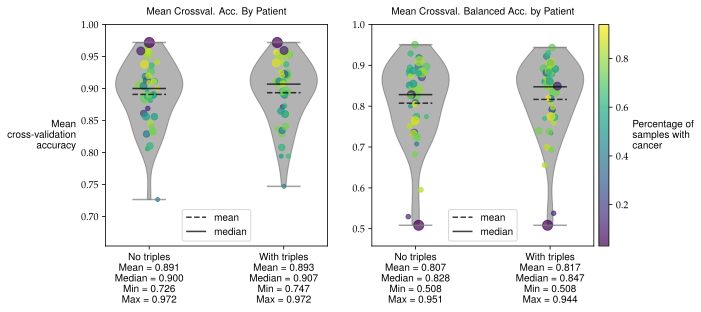

In [47]:
# Plot the classification scores
cmap = "viridis"
plt.rcParams.update({
    'font.size' : 10,
    'text.usetex' : True,
    'axes.titlesize' : 10,
    'font.family' : "sans-serif",
    'font.sans-serif' : 'Helvetica',
    'font.serif' : 'Palatino',
    "figure.dpi" : 300,
})
def plot_classification_scores(classification_results):
    titles_and_scores = {
        "Mean Crossval. Acc. By Patient" : "cv_mean_accuracy",
        "Mean Crossval. Balanced Acc. by Patient" : "cv_mean_balanced_accuracy"
    }
    temp = classification_results.reset_index()
    fig = plt.figure(figsize=(7, 4))
    gs1 = fig.add_gridspec(1, 2, width_ratios=[1, 1], left=0, right=0.97, wspace=0.2)
    gs2 = fig.add_gridspec(1, 1, left=0.98, right=1)
    ax = [fig.add_subplot(gs1[0, 0]), fig.add_subplot(gs1[0, 1])]
    cax = fig.add_subplot(gs2[0, 0])
    legends = {}
    for i, title in enumerate(titles_and_scores):
        ax[i].set_title(title, pad=10)
        score = titles_and_scores[title]
        num_points = []
        num_points.append(int(temp.shape[0]/2))
        _, vplot, sc = weighted_violinplot(
            temp,
            score,
            group_by='Triples',
            # weight='num_samples',
            size='num_samples',
            colour='class_balance',
            ax=ax[i],
            scatter_kwargs={"cmap" : cmap, "norm" : "linear"}
        )
        # handles, labels = ax[i].get_legend_handles_labels()
        legends |= dict(zip(["median", "mean"], [vplot["cmedians"], vplot["cmeans"]], strict=True))
        ax[i].get_legend().remove()
        min_with_tri = temp.loc[temp["Triples"] == True, score].min()
        mean_with_tri = temp.loc[temp["Triples"] == True, score].mean()
        median_with_tri = temp.loc[temp["Triples"] == True, score].median()
        max_with_tri = temp.loc[temp["Triples"] == True, score].max()
        min_without_tri = temp.loc[temp["Triples"] == False, score].min()
        mean_without_tri = temp.loc[temp["Triples"] == False, score].mean()
        median_without_tri = temp.loc[temp["Triples"] == False, score].median()
        max_without_tri = temp.loc[temp["Triples"] == False, score].max()
        ax[i].set_xticks(
            [1, 2],
            labels=[
                "No triples\nMean = {:.3f}\nMedian = {:.3f}\nMin = {:.3f}\nMax = {:.3f}".format(mean_without_tri, median_without_tri, min_without_tri, max_without_tri),
                "With triples\nMean = {:.3f}\nMedian = {:.3f}\nMin = {:.3f}\nMax = {:.3f}".format(mean_with_tri, median_with_tri, min_with_tri, max_with_tri),
            ])
        ax[i].set_ylim(temp[score].min()*0.9, 1.0)
    ax[0].set_ylabel("Mean\ncross-validation\naccuracy", rotation="horizontal", ha="right", labelpad=5, va="center")
    mappable = cm.ScalarMappable(cmap=cmap, norm="linear")
    mappable.set_clim((0.55, 1.0))
    cbar = plt.colorbar(
        mappable=sc[0],
        cax=cax
    )
    cbar.set_label('Percentage of\nsamples with\ncancer', rotation="horizontal", ha="left", va="center")
    ax[0].legend(
        handles = [legends[key] for key in sorted(legends)],
        labels = sorted(legends),
        loc = "lower center"
    )
    ax[1].legend(
        handles = [legends[key] for key in sorted(legends)],
        labels = sorted(legends),
        loc = "lower center"
    )
    # fig.legend(
    #     handles = [legends[key] for key in sorted(legends)],
    #     labels = sorted(legends),
    #     loc = "upper left",
    #     ncol = 1,
    #     bbox_to_anchor = (1, 0.95)
    # )
    # fig.tight_layout()
    fig.savefig("figures/classification_accuracy.pdf", bbox_inches="tight", pad_inches=0)
    fig.savefig("figures/classification_accuracy.svg", bbox_inches="tight", pad_inches=0)
    plt.show()
    
plot_classification_scores(classification_results)

In [3]:
def create_mdi_binned_table(classification_results):
    aux_cols = [
        'num_samples',
        'avg_perc_features',
        'cv_mean_accuracy',
        'cv_mean_balanced_accuracy',
        'baseline',
        'class_balance',
    ]
    mdi_table = classification_results.drop(columns=aux_cols)
    mdi_table.columns = [eval(x) for x in mdi_table.columns]
    stat_names = mdi_table.columns
    celltype_combos = np.unique([' / '.join(stat_name[0]) for stat_name in stat_names])
    records = []
    mdi_dict = mdi_table.to_dict(orient='index')
    for index in mdi_dict.keys():
        patient_id, with_trichromatic = index
        row = mdi_dict[index]
        binned = { celltype_combo : 0.0 for celltype_combo in celltype_combos }
        for stat_name, val in row.items():
            binned[' / '.join(stat_name[0])] += val
        records.append(classification_results.loc[index, aux_cols].to_dict() |
                       { 
                           "patient_id" : patient_id,
                           "Triples" : with_trichromatic,
                       } |
                       binned                     
                      )
    return pd.DataFrame.from_records(records, index=['patient_id', "Triples"])
display(create_mdi_binned_table(classification_results))

,,,num_samples,avg_perc_features,cv_mean_accuracy,cv_mean_balanced_accuracy,baseline,class_balance,CD146,CD146 / CD34,CD146 / CD34 / Cytotoxic T Cell,CD146 / CD34 / Epithelium (imm),...,Podoplanin / T Helper Cell,Podoplanin / T Helper Cell / Treg Cell,Podoplanin / Treg Cell,SMA,SMA / T Helper Cell,SMA / T Helper Cell / Treg Cell,SMA / Treg Cell,T Helper Cell,T Helper Cell / Treg Cell,Treg Cell
patient_id,Triples,Epithelium,,,,,,,,,,,,,,,,,,,,,
10171,False,True,148.0,0.841860,0.882222,0.572436,0.858108,0.141892,0.003642,0.032662,0.000000,0.0,...,0.001347,0.000000,0.003522,0.001849,0.005183,0.000000,0.006434,0.006133,0.012971,0.009457
11818,False,True,302.0,0.817371,0.879121,0.876171,0.546358,0.546358,0.030704,0.037168,0.000000,0.0,...,0.007847,0.000000,0.006053,0.001523,0.007526,0.000000,0.010313,0.014574,0.018396,0.001370
12575,False,True,238.0,0.708257,0.912500,0.901111,0.626050,0.626050,0.008324,0.011847,0.000000,0.0,...,0.000653,0.000000,0.001468,0.002874,0.003240,0.000000,0.008377,0.011894,0.012990,0.048589
13158,False,True,235.0,0.739216,0.943662,0.919787,0.727660,0.727660,0.015631,0.026412,0.000000,0.0,...,0.004328,0.000000,0.004760,0.005453,0.011140,0.000000,0.008094,0.002966,0.000935,0.000877
13309,False,True,494.0,0.763876,0.933557,0.891196,0.775304,0.775304,0.002577,0.002895,0.000000,0.0,...,0.000281,0.000000,0.013676,0.016945,0.004057,0.000000,0.013252,0.000834,0.001382,0.005364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5387,True,False,243.0,0.587795,0.890411,0.882778,0.621399,0.621399,0.001885,0.001107,0.000829,0.0,...,0.017872,0.001570,0.000832,0.003792,0.001857,0.001728,0.007138,0.009188,0.004851,0.000554
5398,True,False,326.0,0.824352,0.840816,0.739752,0.751534,0.751534,0.013507,0.010941,0.032293,0.0,...,0.004339,0.001122,0.003551,0.002954,0.001985,0.001414,0.002942,0.004735,0.006398,0.001260
5531,True,False,121.0,0.789443,0.872973,0.869876,0.611570,0.611570,0.000413,0.000287,0.000690,0.0,...,0.002385,0.002908,0.000858,0.001232,0.003622,0.002026,0.001212,0.014386,0.019760,0.002848


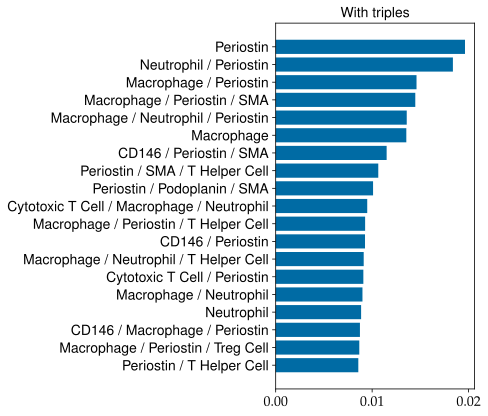

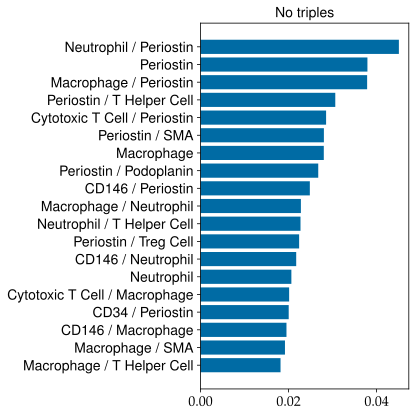

In [55]:
# Plot the average binned MDI score for each feature
def split_celltypes(names):
    return names.split(" / ")

plt.rcParams.update({
    'font.size' : 14,
    'axes.titlesize' : 14
})
def plot_cell_pair_ranks(classification_results, n):
    aux_cols = [
        'num_samples',
        'avg_perc_features',
        'cv_mean_accuracy',
        'cv_mean_balanced_accuracy',
        'baseline',
        'class_balance',
    ]
    mdi_binned_table = create_mdi_binned_table(classification_results).reset_index()
    mdi_binned_table = mdi_binned_table.drop(columns=aux_cols).set_index(["patient_id", "Triples"])
    trichromatic_columns = mdi_binned_table.columns[[
        len(split_celltypes(colname)) == 3 for colname in mdi_binned_table.columns
    ]]
    figsizes = [(7, 6), (6, 6)]
    for i, with_trichromatic in enumerate([True,False]):
        fig, ax = plt.subplots(figsize=figsizes[i])
        temp = mdi_binned_table.reset_index()
        temp = temp.loc[temp["Triples"] == with_trichromatic].drop(columns=["patient_id", "Triples"])
        if not with_trichromatic:
            temp = temp.drop(columns=trichromatic_columns, errors="ignore")
        mean = temp.mean(axis=0)
        sort_order = np.argsort(mean)
        ax.barh(temp.columns[sort_order[-1:-n:-1][::-1]], mean.iloc[sort_order[-1:-n:-1][::-1]])
        axtitle = "With triples" if with_trichromatic else "No triples"
        ax.set_title(axtitle)
        # suptitle = "Feature Importance Across Patients"
        # fig.suptitle(suptitle)
        fig.set_tight_layout(True)
        figname = f"mdi_binned_{with_trichromatic and "trichromatic" or "pairs"}_pca"
        fig.savefig(f"figures/{figname}.pdf", bbox_inches="tight", pad_inches=0)
        fig.savefig(f"figures/{figname}.svg", bbox_inches="tight", pad_inches=0)
        plt.show()

plot_cell_pair_ranks(classification_results, 20)

In [60]:
# Find the number of samples and number of cancer samples
temp = classification_results.xs(True, level="Triples")
# display(temp)
num_cancer = (temp["num_samples"].to_numpy() * temp["class_balance"].to_numpy()).sum()
num_samples = temp["num_samples"].sum()
num_adenoma = num_samples - num_cancer

min_samples_per_patient = temp["num_samples"].min()
max_samples_per_patient = temp["num_samples"].max()
print("Carcinoma samples", num_cancer)
print("Adenoma samples", num_adenoma)
print("Total", num_samples)
print("Min samples per patient", min_samples_per_patient)
print("Max samples per patient", max_samples_per_patient)

Carcinoma samples 7360.0
Adenoma samples 4670.0
Total 12030
Min samples per patient 109
Max samples per patient 700


In [7]:
print(np.unique(patient_ids))
# 2358  5387  5398  5531  5825  5827 10171 11818 12575 13158 13309 14680
# 16118 17903 17989 19606 20068 20374 21455 23559 24505 24922 25914 28717
# 30158 30268 30613 34482 35495 40640 41248 41251 41632 42360 43179 45345
# 45979 48639 48802 49455 50537

# Original IDs before classification:
# 2358 5387 5398 5531 5825 5827 10171 11818 12575 13158 13309 14680
# 16118 17903 17989 19606 20068 20374 21455 23559 24505 24922 25914 28717
# 30158 30268 30613 34482 35495 37315 40640 40814 41248 41251 41632 42360 43179 45345
# 45979 48639 48802 49455 50537

# IDs of patients with no carcinoma ROIs: 37315 and 40814 - these were dropped from the analysis

[ 2358  5387  5398  5531  5825  5827 10171 11818 12575 13158 13309 14680
 16118 17903 17989 19606 20068 20374 21455 23559 24505 24922 25914 28717
 30158 30268 30613 34482 35495 40640 41248 41251 41632 42360 43179 45345
 45979 48639 48802 49455 50537]
